In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import h5py as h5
import pandas as pd
from astropy.cosmology import FlatLambdaCDM, z_at_value
from scipy.stats import spearmanr
import eagle_tools
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os
print(os.getcwd())
import sys
sys.path.insert(0, '.')  # current folder first

notebook_dir = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/scripts'
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

import shap
import timeshap
from timeshap.wrappers import TorchModelWrapper
from timeshap.explainer import TimeShapKernel, global_report, local_pruning, local_event, local_feat, local_cell_level
from timeshap.plot import plot_temp_coalition_pruning, plot_event_heatmap, plot_feat_barplot, plot_cell_level, plot_global_report, plot_global_feat
from timeshap.utils import calc_avg_event


from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import minmax_scale, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy.stats import spearmanr, binned_statistic
import time
import timeit
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import seaborn as sns
import altair as alt
alt.data_transformers.disable_max_rows()

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Use custom matplotlib template
plt.style.use('/users/arirrobe/MachineLearning/MBH-EBind-MorphoKinem/mnras_mpl.stylesheet')

cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089)

omega_b = 0.0482519
omega_0 = 0.307
omega_lambda = 0.693
Z_solar = 0.012663729
M_solar = 1.98841e33
eps_r = 0.1
eps_f = 0.15
c = 2.99792458e10
yr = 3.154e7
H_0 = 67.77
H_0_cgs = 3.2407789e-18
Mpc = 3.086e24 
kpc = 3.086e21
pc = 3.086e18
G = 6.67e-8
km = 1e5
h = 0.6777
boxsize = 67770/h
Z_w = 0.002
gamma_wz = 2
f_wz = 0.25
ebar_w = 3.6
N_SNII = 0.0118
rho_crit =  8.6e-30 #g/cm^3 given by 3H^2/8piG

cgs_conv_mass = 1.989e+43
cgs_conv_sfr = 6.304278922345484e+25
cgs_conv_birthdensity = 6.769911178294543e-31
cgs_conv_acc_rate = 6.445909132449984e+23
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21

dm_particlemass = 9.7e6*M_solar

load_path = '/users/arirrobe/MachineLearning/EAGLE_Datasets'
archive_load_path = '/mnt/scratch/users/arijdavi/hpcdata0_backup/EAGLE_catalogues/L0100N1504/REFERENCE/028_z000p000'
save_path = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/outputs/TimeSHAP'

/users/arirrobe/MachineLearning


In [3]:
with h5.File(f'{load_path}/L0100N1504_AllHaloProperties.h5', 'r') as fi:
    matched_group_nums = fi['/GroupNumber'][()].astype(np.int32)
    kappa_co = fi['kappa_co'][()]
    e_agn = fi['E_AGN'][()]
    e_bind = fi['E_Bind'][()]
    assembly_time = fi['AssemblyTime'][()]
    conc = fi['Vmax_V200'][()]
    m200 = fi['M200'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_NewFeedback.h5', 'r') as fi:
    group_nums = fi['/GroupNumber'][()].astype(np.int64)
    m_bh = fi['/M_BH_INTERP/'][()][:,0]
fi.close()

with h5.File(f'{load_path}/L0100N1504_MorphoKinem.h5', 'r') as fi:
    all_morpho_kinem = fi['AllMorphoKinem'][()]
    all_morpho_z = fi['AllMorphoKinem'][()][:,1]
    all_ellipticity = fi['AllMorphoKinem'][()][:,3]
    all_triaxiality = fi['AllMorphoKinem'][()][:,4]
fi.close()

with h5.File(f'{load_path}/L0100N1504_All_DiscToTotal.h5', 'r') as fi:
    all_disc_to_total = fi['All_DiscToTotal'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_kappa_gas.h5', 'r') as fi:
    all_kappa_gas = fi['kappa_gas'][()]
fi.close()

all_kappa = np.array(pd.read_csv(f'{load_path}/AllKappaInfo.csv', index_col=0, skiprows=0))

missing_idx = []
for i, gn in enumerate(matched_group_nums):
    if gn == 1:
        all_z = all_kappa[all_kappa[:,0] == gn, 1]
    
    galaxy = all_kappa[all_kappa[:,0] == gn]
    if galaxy.shape[0] <= 8:
        missing_idx.append(gn)

missing_idx = np.unique(missing_idx)
print(missing_idx)
print(len(missing_idx))

all_kappa = np.delete(all_kappa, np.argwhere(np.isin(all_kappa[:,0], missing_idx)), 0)
all_kappa_gas = np.delete(all_kappa_gas, np.argwhere(np.isin(all_kappa_gas[:,0], missing_idx)), 0)
all_triaxiality = np.delete(all_triaxiality, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_ellipticity = np.delete(all_ellipticity, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_z = np.delete(all_morpho_z, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_kinem = np.delete(all_morpho_kinem, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_disc_to_total = np.delete(all_disc_to_total, np.argwhere(np.isin(all_disc_to_total[:,0], missing_idx)), 0)

all_kappa_gas[:,2][np.where(np.isnan(all_kappa_gas[:,2]))] = np.min(all_kappa_gas[:,2][np.where(~np.isnan(all_kappa_gas[:,2]))])
all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] == -10)] = np.min(all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] != -10)])
    
kappa_co = all_kappa[all_kappa[:,1]<= 0.001, 2]
kappa_gas = all_kappa_gas[all_kappa_gas[:,1]<= 0.001, 2]
triax_z0 = all_triaxiality[all_morpho_z <= 0.001]
ellip_z0 = all_ellipticity[all_morpho_z <= 0.001]
disc_to_total = all_disc_to_total[all_disc_to_total[:,1] <= 0.001, 2]

all_alpha_m = all_morpho_kinem.copy()[:,:2]
new_col = ((all_ellipticity**2) + 1 - all_triaxiality)/2
all_alpha_m = np.concatenate([all_alpha_m, new_col[:, None]], axis=1)
alpha_m = all_alpha_m[all_alpha_m[:,1] <= 0.001]

idx_in_group_nums = np.array([np.where(group_nums == gn)[0][0] for gn in matched_group_nums])
m_bh = m_bh[idx_in_group_nums]


with h5.File(f'{archive_load_path}/DMO_binding_energies.hdf5', 'r') as fi:
    e_bind_2500 = fi['Particle_E_2500'][()]
    e_bind_gn = fi['GroupNumber'][()]
fi.close()


idx_in_ebind_gn = np.array([np.where(e_bind_gn == gn)[0][0] for gn in matched_group_nums])
e_bind_2500 = e_bind_2500[idx_in_ebind_gn]

with h5.File(f'{load_path}/L0100N1504_Mstar_MBH_Histories.h5', 'r') as fi:
    all_mstar_mbh = fi['Mstar_MBH_Arr'][()]
fi.close()

all_mstar_mbh = np.delete(all_mstar_mbh, np.argwhere(all_mstar_mbh[:,0]==0), 0)
all_mstar_mbh = all_mstar_mbh[np.lexsort((all_mstar_mbh[:,1], all_mstar_mbh[:,0]))]


all_mstar = np.delete(all_mstar_mbh, 2, 1)
all_mbh = all_mstar_mbh[:,:3]
all_mbh[all_mbh[:,1]<= 0.001, 2] = m_bh

all_mstar = np.delete(all_mstar, np.argwhere(np.isin(all_mstar[:,0], missing_idx)), 0)
all_mbh = np.delete(all_mbh, np.argwhere(np.isin(all_mbh[:,0], missing_idx)), 0)

m_star = all_mstar[all_mstar[:,1]<= 0.001, 2]
m_bh = all_mbh[all_mbh[:,1]<= 0.001, 2]

with h5.File(f'{load_path}/L0100N1504_M200_Histories.h5', 'r') as fi:
    all_m200 = fi['M200_Histories'][()]
fi.close()

all_m200[all_m200[:,1]<= 0.001, 2] = m200
all_m200 = np.delete(all_m200, np.argwhere(np.isin(all_m200[:,0], missing_idx)), 0)
# all_m200 = all_m200[np.argwhere((np.isin(all_mbh[:,0], all_m200[:,0])) & (np.isin(all_mbh[:,1], all_m200[:,1]))).ravel()]

pairs_mbh = np.core.records.fromarrays(
    [all_mbh[:,0], all_mbh[:,1]],
    names='group,z'
)

pairs_m200 = np.core.records.fromarrays(
    [all_m200[:,0], all_m200[:,1]],
    names='group,z'
)

mask = np.isin(pairs_m200, pairs_mbh)
all_m200 = all_m200[mask]


with h5.File(f'{load_path}/L0100N1504_30kpcApertureMaxMassAllMergers.h5', 'r') as fi:
    all_mergers = fi['AllMergerEvents'][()]  # (gn, z, major_mergers, minor_mergers, Mstar_Acc, f_exsitu)
fi.close()
all_mergers = np.delete(all_mergers, np.argwhere(np.isin(all_mergers[:,0], missing_idx)), 0)


m200 = np.log10(m200)
all_mstar[:,2] = np.log10(all_mstar[:,2])
all_mbh[:,2] = np.log10(all_mbh[:,2])
all_m200[:,2] = np.log10(all_m200[:,2])
m_star = np.log10(m_star)
m_bh = np.log10(m_bh)
e_agn = np.log10(e_agn)
e_bind = np.log10(np.abs(e_bind))
e_bind_2500 = np.log10(np.abs(e_bind_2500) * cgs_conv_mass*cgs_conv_vel / h)

missing_idx = np.argwhere(np.isin(matched_group_nums, missing_idx)).ravel()
matched_group_nums = np.delete(matched_group_nums, missing_idx)
assembly_time = np.delete(assembly_time, missing_idx)
m200 = np.delete(m200, missing_idx)
e_agn = np.delete(e_agn, missing_idx)
e_bind = np.delete(e_bind, missing_idx)
e_bind_2500 = np.delete(e_bind_2500, missing_idx)
e_bind = e_bind_2500

e_bind_sorted = e_bind[np.argsort(e_bind)]
m_star_ebind = m_star[np.argsort(e_bind)]
matched_group_nums_ebind = matched_group_nums[np.argsort(e_bind)]
m200_ebind = m200[np.argsort(e_bind)]
m_bh_ebind = m_bh[np.argsort(e_bind)]
kappa_co_ebind = kappa_co[np.argsort(e_bind)]
kappa_gas_ebind = kappa_gas[np.argsort(e_bind)]
alpha_m_ebind = alpha_m[np.argsort(e_bind)]
disc_to_total_ebind = disc_to_total[np.argsort(e_bind)]

all_redshifts = all_kappa[all_kappa[:,0]==matched_group_nums[0],1][::-1][:-1]
t_cosmic = cosmology.age(all_redshifts).value
print(all_redshifts)
print(t_cosmic)

n_samples = len(matched_group_nums)
n_timesteps = len(all_redshifts)
n_features = 4

# Initialize X with -10 to mark "missing"
X = np.full((n_samples, n_timesteps, n_features), -10.0, dtype=np.float32)

# Create a mapping from galaxy ID -> row index
group_to_idx = {g: i for i, g in enumerate(matched_group_nums)}

for t_idx, z in enumerate(all_redshifts):
    # kappa_star
    mask = np.isclose(all_kappa[:, 1], z)
    for row in all_kappa[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 0] = row[2]

    # kappa_gas
    mask = np.isclose(all_kappa_gas[:, 1], z)
    for row in all_kappa_gas[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 1] = row[2]

    # alpha_m
    mask = np.isclose(all_alpha_m[:, 1], z)
    for row in all_alpha_m[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 2] = row[2]

    # D/T
    mask = np.isclose(all_disc_to_total[:, 1], z)
    for row in all_disc_to_total[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 3] = row[2]

    # # Mstar_Accreted
    # mask = np.isclose(all_mergers[:, 1], z)
    # for row in all_mergers[mask]:
    #     g = int(row[0])
    #     if g in group_to_idx:
    #         X[group_to_idx[g], t_idx, 4] = row[4]

    # # f_exsitu
    # for row in all_mergers[mask]:
    #     g = int(row[0])
    #     if g in group_to_idx:
    #         X[group_to_idx[g], t_idx, 5] = row[-1]

print("X shape:", X.shape)


ebind_range = (e_bind >= 58) & (e_bind <= 58.5)
low_kappa = np.percentile(kappa_co[ebind_range], 25)
high_kappa = np.percentile(kappa_co[ebind_range], 75)

low_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] <= low_kappa]
high_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] >= high_kappa]
test_kappa_ids = matched_group_nums[ebind_range][(kappa_co[ebind_range] <= low_kappa) | (kappa_co[ebind_range] >= high_kappa)]

gal_mask_train = ~np.isin(matched_group_nums, test_kappa_ids)
gal_mask_test  = np.isin(matched_group_nums, test_kappa_ids)

# X_train = X[gal_mask_train, :, :]
# X_test  = X[gal_mask_test, :, :]

# y_train = m_bh[gal_mask_train]
# y_test  = m_bh[gal_mask_test]

# Train-test split
y = m_bh
X_train, X_test, y_train, y_test, ellspi_train, ellspi_test = train_test_split(X, y, matched_group_nums, test_size=0.1, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val, ellspi_train, ellspi_val = train_test_split(X_train, y_train, ellspi_train, test_size=0.1, shuffle=True, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# # Copy arrays to avoid overwriting
# X_train_scaled = X_train.copy()
# X_val_scaled  = X_val.copy()
# X_test_scaled  = X_test.copy()

# # Scale per feature across all galaxies and timesteps
# N, T, F = X_train.shape
# scaler = MinMaxScaler(feature_range=(0, 1))

# for f in range(F):
#     # Flatten the feature across all samples and timesteps
#     feature_train = X_train[:, :, f].flatten()
#     valid_mask = feature_train > -10

#     # Only fit/transform valid values
#     feature_train_scaled = np.zeros_like(feature_train)
#     feature_train_scaled[valid_mask] = scaler.fit_transform(feature_train[valid_mask].reshape(-1, 1)).flatten()
#     feature_train_scaled[~valid_mask] = -10  # keep missing values as -10

#     # Put it back
#     X_train_scaled[:, :, f] = feature_train_scaled.reshape(N, T)

#     # Apply same scaler to validation
#     feature_val = X_val[:, :, f].flatten()
#     valid_mask_val = feature_val > -10
#     feature_val_scaled = np.zeros_like(feature_val)
#     feature_val_scaled[valid_mask_val] = scaler.transform(feature_val[valid_mask_val].reshape(-1, 1)).flatten()
#     feature_val_scaled[~valid_mask_val] = -10
#     X_val_scaled[:, :, f] = feature_val_scaled.reshape(X_val.shape[0], T)
    
#     # Apply same scaler to test
#     feature_test = X_test[:, :, f].flatten()
#     valid_mask_test = feature_test > -10
#     feature_test_scaled = np.zeros_like(feature_test)
#     feature_test_scaled[valid_mask_test] = scaler.transform(feature_test[valid_mask_test].reshape(-1, 1)).flatten()
#     feature_test_scaled[~valid_mask_test] = -10
#     X_test_scaled[:, :, f] = feature_test_scaled.reshape(X_test.shape[0], T)
    



# Copy arrays to avoid overwriting
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

N, T, F = X_train.shape

for f in range(F):
    scaler = StandardScaler()
    
    feature_train = X_train[:, :, f].flatten()
    valid_mask = feature_train > -10
    
    feature_train_scaled = np.zeros_like(feature_train)
    feature_train_scaled[valid_mask] = scaler.fit_transform(feature_train[valid_mask].reshape(-1,1)).flatten()
    
    feature_train_scaled[~valid_mask] = 0.0
    X_train_scaled[:,:,f] = feature_train_scaled.reshape(N, T)
    
    # val
    feature_val = X_val[:,:,f].flatten()
    valid_mask_val = feature_val > -10
    feature_val_scaled = np.zeros_like(feature_val)
    feature_val_scaled[valid_mask_val] = scaler.transform(feature_val[valid_mask_val].reshape(-1,1)).flatten()
    X_val_scaled[:,:,f] = feature_val_scaled.reshape(X_val.shape[0], T)
    
    # test
    feature_test = X_test[:,:,f].flatten()
    valid_mask_test = feature_test > -10
    feature_test_scaled = np.zeros_like(feature_test)
    feature_test_scaled[valid_mask_test] = scaler.transform(feature_test[valid_mask_test].reshape(-1,1)).flatten()
    X_test_scaled[:,:,f] = feature_test_scaled.reshape(X_test.shape[0], T)
    

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_scaled   = y_scaler.transform(y_val.reshape(-1,1)).flatten()
y_test_scaled  = y_scaler.transform(y_test.reshape(-1,1)).flatten()

[ 643  741  799  970 1039 1280 1447 1760 1772 1851 2064 2080 2323 2521
 2566 2649 2656 2682 2780 2811 2854 2925 3016 3022 3143 3274 3356 3387
 3424 3469 3547 3615 3643 3702 3777 3952]
36


divide by zero encountered in log10


[4.4852138  3.9836636  3.5279765  3.0165045  2.4784133  2.237037
 2.0124102  1.7369658  1.4867073  1.2593315  1.0041217  0.86505055
 0.7356296  0.6151898  0.5031073  0.36566857 0.27090108 0.18270987
 0.10063854]
[ 1.34472796  1.551595    1.78984634  2.13875274  2.64578454  2.94114736
  3.26795588  3.75748139  4.31472894  4.9464489   5.85033684  6.45755519
  7.11544418  7.82491315  8.58613433  9.68036537 10.55842338 11.48297519
 12.4509065 ]
X shape: (3374, 19, 4)
(2732, 19, 4) (304, 19, 4) (338, 19, 4)
(2732,) (304,) (338,)


In [4]:
''' 
Create the LSTM class for predicting quiescence at z=0. LSTM init is defined by:
input_dim -> Number of features
hidden_dim -> Size of the hidden state in the LSTM (bigger = more complex)
num_layers -> Number of layers in the LSTM (bigger = more complex)
bidirectional -> Enables bidirectionality, where the model looks forwards and backwards through time (turn off for simpler models)
'''

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, bidirectional=False):
        super().__init__()

        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        # Single continuous output
        self.output_layer = nn.Linear(hidden_dim * self.num_directions, 1)

    def forward(self, x):
        """
        x: (batch_size, time_steps, input_dim)
        """
        lstm_out, _ = self.lstm(x)

        # Use last timestep representation
        last_hidden = lstm_out[:, -1, :]   # (batch_size, hidden_dim * num_directions)

        y_pred = self.output_layer(last_hidden)
        return y_pred

In [5]:
def objective(trial):

    # ------------------
    # Hyperparameters to tune
    # ------------------
    hidden_dim = trial.suggest_int("hidden_dim", 32, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # ------------------
    # Initialisation
    # ------------------
    
    input_dim = X_train.shape[2]     # Feature Dimension
    timesteps = X_train.shape[1]     # Time Dimension
    
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
    
    
    # ------------------
    # Model
    # ------------------
    model = LSTMRegressor(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        bidirectional=False
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ------------------
    # Training loop 
    # ------------------
    n_epochs = 50   # shorter for Optuna
    
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(X_train_tensor.size(0))

        for i in range(0, X_train_tensor.size(0), batch_size):
            idx = perm[i:i+batch_size]
            x_batch = X_train_tensor[idx]
            y_batch = y_train_tensor[idx].view(-1, 1)

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        # ---- validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_tensor)
            val_loss = criterion(
                val_preds,
                y_val_tensor.view(-1, 1)
            ).item()

        # Pruning (early stopping for bad trials)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_loss


In [6]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=40)

[I 2026-02-12 15:42:46,175] A new study created in memory with name: no-name-f8da0e58-2623-4903-a316-4dcc64f0c220
[I 2026-02-12 15:44:05,025] Trial 0 finished with value: 0.18059726059436798 and parameters: {'hidden_dim': 96, 'num_layers': 4, 'lr': 0.000291063591313307, 'weight_decay': 6.251373574521755e-05, 'batch_size': 16}. Best is trial 0 with value: 0.18059726059436798.
[I 2026-02-12 15:45:28,627] Trial 1 finished with value: 0.17775069177150726 and parameters: {'hidden_dim': 224, 'num_layers': 3, 'lr': 0.0002607024758370766, 'weight_decay': 1.1527987128232402e-06, 'batch_size': 16}. Best is trial 1 with value: 0.17775069177150726.
[I 2026-02-12 15:45:34,165] Trial 2 finished with value: 0.7993069887161255 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'lr': 4.059611610484306e-05, 'weight_decay': 3.752055855124284e-05, 'batch_size': 64}. Best is trial 1 with value: 0.17775069177150726.
[I 2026-02-12 15:46:07,943] Trial 3 finished with value: 0.3040432929992676 and parameters:

In [ ]:
# Initialise input parameters for LSTM
input_dim = X_train.shape[2]     # Feature Dimension
timesteps = X_train.shape[1]     # Time Dimension
epochs = 100
batch_size = study.best_params['batch_size']
# hidden_dim = 128
# epochs = 200
# lr = 1e-4

# Model, loss, optimizer
model = LSTMRegressor(
    input_dim=input_dim,
    hidden_dim=study.best_params['hidden_dim'],
    num_layers=study.best_params['num_layers'],
    bidirectional=False
)

criterion = nn.MSELoss()  # regression loss
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'], weight_decay=study.best_params['weight_decay'])

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)


# Lists to store losses
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.size(0))
    batch_loss = []

    for i in range(0, X_train_tensor.size(0), batch_size):
        idx = perm[i:i+batch_size]
        x_batch = X_train_tensor[idx]
        y_batch = y_train_tensor[idx].view(-1, 1)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    # Average training loss over batches
    avg_train_loss = np.mean(batch_loss)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train_tensor)
        train_preds_np = train_preds.cpu().numpy().flatten()
        train_labels_np = y_train_tensor.cpu().numpy().flatten()
        
        val_preds = model(X_val_tensor)
        val_preds_np = val_preds.cpu().numpy().flatten()
        val_labels_np = y_val_tensor.cpu().numpy().flatten()

        val_loss = np.mean((val_preds_np - val_labels_np) ** 2)
        val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train MSE = {avg_train_loss:.3f} | "
        f"Validation MSE = {val_loss:.3f} | "
        f"Train RMSE = {np.sqrt(avg_train_loss):.3f} | "
        f"Validation RMSE = {np.sqrt(val_loss):.3f}"
    )


5.494621182015909 9.588164627444359
R² = 0.794
True std: 0.88523585
Pred std: 0.73319566
True mean: 6.82143
Pred mean: 6.82715


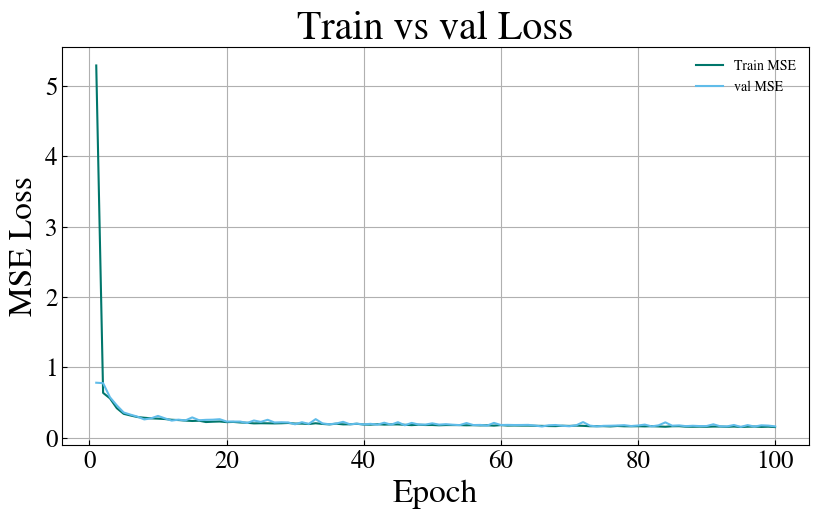

5.494621182015909 9.588164627444359
Baseline RMSE (dex): 1.105
Model RMSE (dex):    6.848
Improvement:         -519.4%
RMSE (dex) = 5.484
Typical mass error ≈ factor of 304489.91


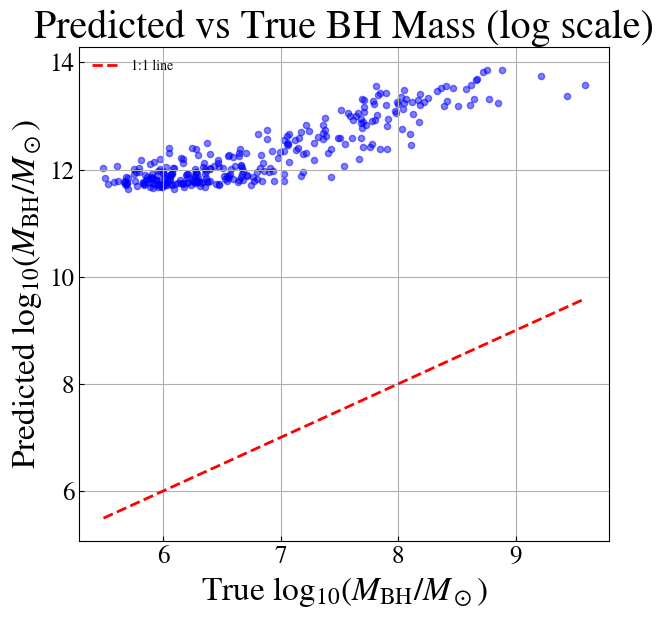

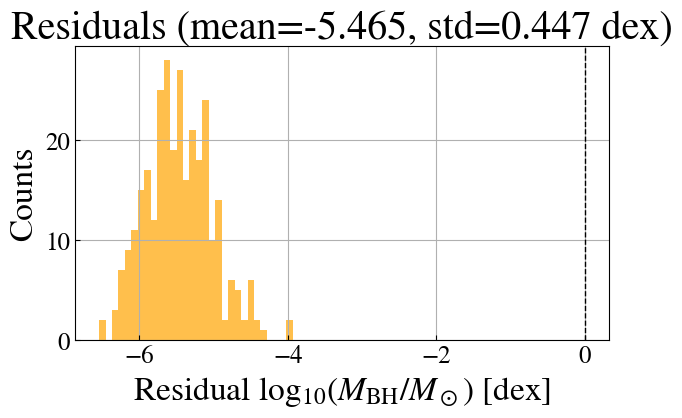

In [8]:
print(np.min(y_val), np.max(y_val))

y_true = y_val_tensor.cpu().numpy().flatten()
y_pred = val_preds_np  # already flattened

r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R² = {r2:.3f}")
print("True std:", np.std(y_true))
print("Pred std:", np.std(y_pred))
print("True mean:", np.mean(y_true))
print("Pred mean:", np.mean(y_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train MSE")
plt.plot(range(1, epochs+1), val_losses, label="val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train vs val Loss")
plt.legend()
plt.grid(True)
plt.show()

print(np.min(y_val), np.max(y_val))


y_train_mean = np.mean(y_train_scaled)

baseline_preds = np.full_like(y_val_scaled, y_train_mean)
baseline_mse = np.mean((y_val_scaled - baseline_preds)**2)
baseline_rmse = np.sqrt(baseline_mse)
model_rmse = np.sqrt(np.mean((y_val_scaled - val_preds_np)**2))

print(f"Baseline RMSE (dex): {baseline_rmse:.3f}")
print(f"Model RMSE (dex):    {model_rmse:.3f}")
print(f"Improvement:         {(1 - model_rmse/baseline_rmse)*100:.1f}%")



y_true_phys = y_scaler.inverse_transform(y_val_scaled.reshape(-1,1)).flatten()
y_pred_phys = y_scaler.inverse_transform(val_preds_np.reshape(-1,1)).flatten()

rmse_phys = np.sqrt(np.mean((y_true_phys - y_pred_phys)**2))
print(f"RMSE (dex) = {rmse_phys:.3f}")
print(f"Typical mass error ≈ factor of {10**rmse_phys:.2f}")

plt.figure(figsize=(6,6))
plt.scatter(y_true_phys, y_pred_phys, alpha=0.5, color='blue', s=20)
plt.plot([y_true_phys.min(), y_true_phys.max()],
         [y_true_phys.min(), y_true_phys.max()],
         'r--', lw=2, label='1:1 line')
plt.xlabel(r'True log$_{10}(M_{\rm BH}/M_\odot)$')
plt.ylabel(r'Predicted log$_{10}(M_{\rm BH}/M_\odot)$')
plt.title('Predicted vs True BH Mass (log scale)')
plt.legend()
plt.grid(True)
plt.show()

# --- Residuals (dex) ---
residuals = y_true_phys - y_pred_phys

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color='orange', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel(r'Residual log$_{10}(M_{\rm BH}/M_\odot)$ [dex]')
plt.ylabel('Counts')
plt.title(f'Residuals (mean={np.mean(residuals):.3f}, std={np.std(residuals):.3f} dex)')
plt.grid(True)
plt.show()

R² = 0.701
MSE = 0.227
RMSE = 0.476


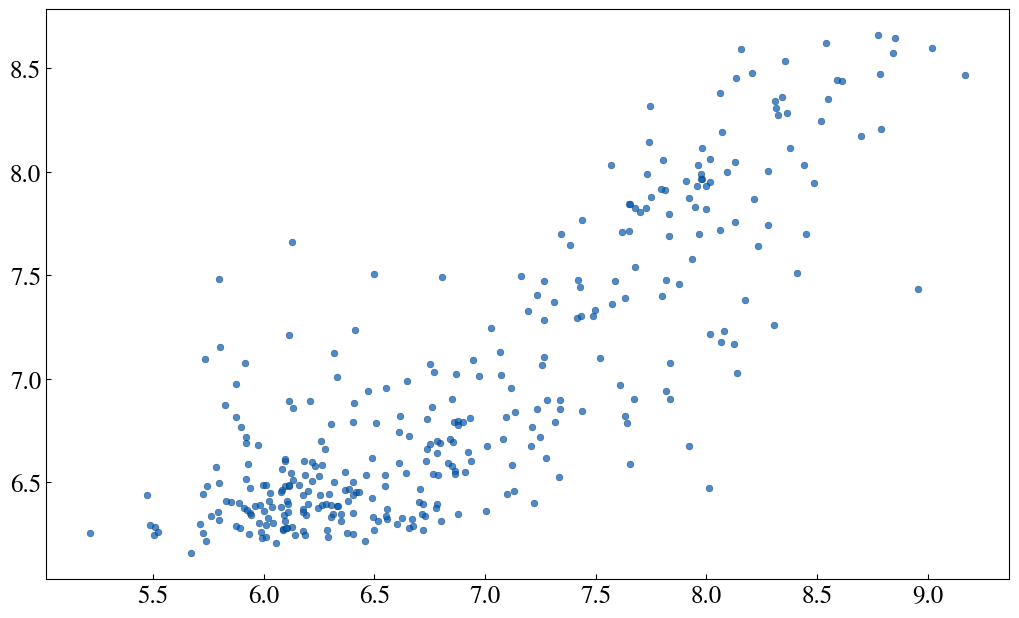

In [280]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_preds_np = test_preds.cpu().numpy().flatten()
    test_labels_np = y_test_tensor.cpu().numpy().flatten()

mse = np.mean((test_preds_np - test_labels_np) ** 2)
rmse = np.sqrt(np.mean((test_preds_np - test_labels_np) ** 2))
r2 = 1 - np.sum((test_labels_np - test_preds_np)**2) / np.sum((test_labels_np - np.mean(test_preds_np))**2)
print(f'R² = {r2:.3f}')
print(f'MSE = {mse:.3f}')
print(f'RMSE = {rmse:.3f}')

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(test_labels_np, test_preds_np, s=25, c='#005AB5', edgecolors='k', linewidths=0.2, alpha=0.7)

In [23]:
feature_names = ['$\\kappa_{\\rm co,\\star}$', '$\\kappa_{\\rm co,gas}$', '$\\alpha_{\\rm m}$', 'D/T']

model_wrapped = TorchModelWrapper(model)
f = lambda x, y=None: model_wrapped.predict_last_hs(x, y)

background = np.mean(X_train_scaled, axis=0, keepdims=True)
print(background.shape)

(1, 19, 4)


In [97]:
def timeshap_dataframe(X, feature_names):
    """
    X: (N, T, F)
    returns DataFrame compatible with TimeSHAP global methods
    """
    N, T, F = X.shape

    rows = []
    for i in range(N):
        for t in range(T):
            row = {
                'sequence_id': i,
                'time': t,
            }
            for f in range(F):
                row[feature_names[f]] = X[i, t, f]
            rows.append(row)

    return pd.DataFrame(rows)

feature_names = [
    r'$\kappa_{\rm co,\star}$',
    r'$\kappa_{\rm co,gas}$',
    r'$\alpha_{\rm m}$',
    'D/T'
]

df_test = timeshap_dataframe(X_test_scaled, feature_names)

In [239]:
average_event = np.mean(X_train_scaled, axis=0)  # (T, F)
# average_event = np.mean(X_train_scaled[ellspi_train], axis=0)
model_wrapped = TorchModelWrapper(model)

def f_hs(x, y=None):
    """
    x: np.ndarray of shape (N, T, F)
    returns: (N,) or (N, 1)
    """
    return model_wrapped.predict_last_hs(x, y)

model_features = feature_names

plot_features = {
    r'$\kappa_{\rm co,\star}$': r'$\kappa_{\rm co,\star}$',
    r'$\kappa_{\rm co,gas}$': r'$\kappa_{\rm co,gas}$',
    r'$\alpha_{\rm m}$': r'$\alpha_{\rm m}$',
    'D/T': 'D/T'
}

pruning_dict = {
    'tol': [0.0001],   # Small tolerance
    'path': 'outputs/prun_all.csv'
}

event_dict = {
    'path': 'outputs/event_all.csv',
    'rs': 42,
    'nsamples': 32000
}

feature_dict = {
    'path': 'outputs/feature_all.csv',
    'rs': 42,
    'nsamples': 32000,
    'feature_names': model_features,   # list of column names
    'plot_features': plot_features     # dict (THIS FIXES THE ERROR)
}


schema = list(df_test.columns)

sequence_id_feat = 'sequence_id'
time_feat = 'time'

print(schema)

set(model_features).issubset(set(schema))

['sequence_id', 'time', '$\\kappa_{\\rm co,\\star}$', '$\\kappa_{\\rm co,gas}$', '$\\alpha_{\\rm m}$', 'D/T']


True

In [240]:
print(df_test[sequence_id_feat].nunique())  # number of sequences
print(df_test.groupby(sequence_id_feat).size().unique())  # length of sequences

df_test['sequence_id'] = df_test['sequence_id'].astype(int)
df_test['time'] = df_test['time'].astype(int)

for col in feature_names:
    df_test[col] = pd.to_numeric(df_test[col])

338
[19]


In [241]:
prun_stats, global_plot = global_report(
    f_hs,
    df_test,
    pruning_dict,
    event_dict,
    feature_dict,
    average_event,
    model_features,
    schema,
    sequence_id_feat,
    time_feat,
    append_to_files=True
)

Calculating pruning algorithm
Calculating event data
Calculating feat data
Calculating pruning indexes


elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


In [242]:
print(t_cosmic)
global_plot

[ 1.34472796  1.551595    1.78984634  2.13875274  2.64578454  2.94114736
  3.26795588  3.75748139  4.31472894  4.9464489   5.85033684  6.45755519
  7.11544418  7.82491315  8.58613433  9.68036537 10.55842338 11.48297519
 12.4509065 ]


the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.


alt.VConcatChart(...)

In [195]:
def plot_global_event_timeshap(
    event_data: pd.DataFrame,
    time_col='time',
    shap_col='Shapley Value',
    figsize=(7, 4),
    point_alpha=0.08,
    point_size=10,
    mean_color='tab:red',
    scatter_color='tab:blue',
    percentile_clip=(1, 99),
):
    """
    Matplotlib clone of TimeSHAP global event-level plot.

    Parameters
    ----------
    event_data : pd.DataFrame
        Must contain columns [time_col, shap_col]

    percentile_clip : tuple
        Percentiles for y-axis clipping
    """

    df = event_data.copy()
    df = df[df[shap_col].notna()]

    # Mean SHAP per timestep
    mean_df = (
        df.groupby(time_col)[shap_col]
        .mean()
        .reset_index()
        .sort_values(time_col)
    )

    if percentile_clip is not None:
        # Y-axis limits (robust)
        v = df[shap_col].values
        lo, hi = np.percentile(v, percentile_clip)
        lim = max(abs(lo), abs(hi))
    else:
        lim = max(abs(df[shap_col].min()), abs(df[shap_col].max()))

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter all SHAP values
    ax.scatter(
        df[time_col],
        df[shap_col],
        s=point_size,
        alpha=point_alpha,
        color=scatter_color,
        rasterized=True
    )

    # Mean SHAP line
    ax.scatter(
        mean_df[time_col],
        mean_df[shap_col],
        color=mean_color,
        s=5*point_size,
        label='Mean'
    )

    print(len(df[time_col]))
    # Formatting
    ax.axhline(0, color='k', lw=1, alpha=0.6)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('SHAP value')
    ax.set_ylim(-lim, lim)
    ax.legend(frameon=False)

    return fig, ax



def plot_global_feat_matplotlib(
    feat_data: pd.DataFrame,
    feature_order=None,
    axis_lim=None,
    figsize=(6, 4),
    point_alpha=0.3,
    point_size=7,
    mean_size=80,
):
    """
    Matplotlib version of TimeSHAP global feature plot
    """

    # Split raw SHAP values
    df = feat_data.copy()
    df = df[df['Shapley Value'].notna()]

    # Compute mean per feature
    mean_df = (
        df.groupby('Feature')['Shapley Value']
        .mean()
        .reset_index()
    )

    # Sort features by |mean|
    mean_df['abs_mean'] = mean_df['Shapley Value'].abs()
    mean_df = mean_df.sort_values('abs_mean', ascending=True)

    features = mean_df['Feature'].values
    y_pos = np.arange(len(features))

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter raw SHAP values
    for i, feat in enumerate(features):
        vals = df.loc[df['Feature'] == feat, 'Shapley Value']
        ax.scatter(
            vals,
            np.full_like(vals, i),
            s=point_size,
            alpha=point_alpha,
            color='tab:blue'
        )

    # Plot mean SHAP values
    ax.scatter(
        mean_df['Shapley Value'],
        y_pos,
        s=mean_size,
        color='tab:red',
        zorder=3,
        label='Mean'
    )

    # Formatting
    ax.axvline(0, color='k', lw=1, alpha=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.set_xlabel('SHAP value')

    if axis_lim is not None:
        ax.set_xlim(axis_lim)

    ax.legend(frameon=False)
    return fig, ax





def plot_global_feat_violin(
    feat_data: pd.DataFrame,
    axis_percentiles=(1, 99),
    figsize=(7, 4),
    violin_width=0.8,
    mean_size=70,
    violin_color='tab:blue',
    mean_color='tab:red'
):
    """
    Matplotlib TimeSHAP global feature violin plot.

    Parameters
    ----------
    feat_data : pd.DataFrame
        Must contain columns:
        ['Feature', 'Shapley Value']
        (optionally also 'time', 'sequence_id')

    axis_percentiles : tuple
        Percentiles used to clip x-axis (default: 1–99)

    figsize : tuple
        Figure size

    violin_width : float
        Width of each violin

    mean_size : int
        Marker size for mean points
    """

    # Keep only raw SHAP values
    df = feat_data.copy()
    df = df[df['Shapley Value'].notna()]

    # Compute mean SHAP per feature
    mean_df = (
        df.groupby('Feature')['Shapley Value']
        .mean()
        .reset_index()
    )

    # Sort features by |mean SHAP|
    mean_df['abs_mean'] = mean_df['Shapley Value'].abs()
    mean_df = mean_df.sort_values('abs_mean', ascending=True)

    features = mean_df['Feature'].values
    y_pos = np.arange(len(features))

    # Axis limits via percentile clipping
    v = df['Shapley Value'].values
    lo, hi = np.percentile(v, axis_percentiles)
    lim = max(abs(lo), abs(hi))

    fig, ax = plt.subplots(figsize=figsize)

    # Draw violins
    for i, feat in enumerate(features):
        vals = df.loc[df['Feature'] == feat, 'Shapley Value'].values
        if len(vals) == 0:
            continue

        vp = ax.violinplot(
            vals,
            positions=[i],
            vert=False,
            widths=violin_width,
            showmeans=False,
            showextrema=False,
            showmedians=False
        )

        for body in vp['bodies']:
            body.set_facecolor(violin_color)
            body.set_edgecolor('black')
            body.set_alpha(0.35)

    # Plot mean SHAP values
    ax.scatter(
        mean_df['Shapley Value'],
        y_pos,
        s=mean_size,
        color=mean_color,
        zorder=3,
        label='Mean'
    )

    # Formatting
    ax.axvline(0, color='k', lw=1, alpha=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.set_xlim(-lim, lim)
    ax.set_xlabel('SHAP value')

    ax.legend(frameon=False)

    return fig, ax


6399


The figure layout has changed to tight


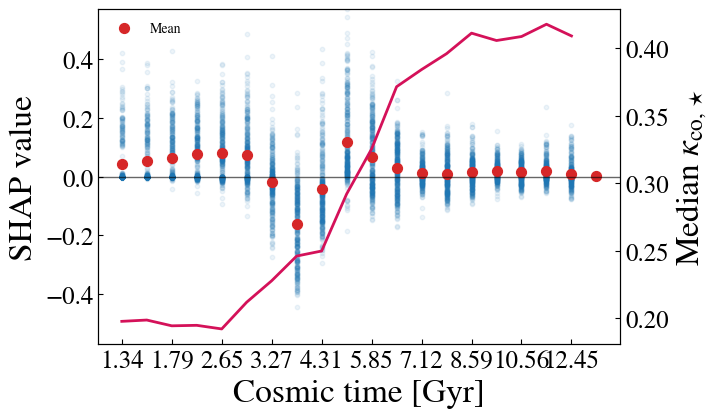

6399


The figure layout has changed to tight


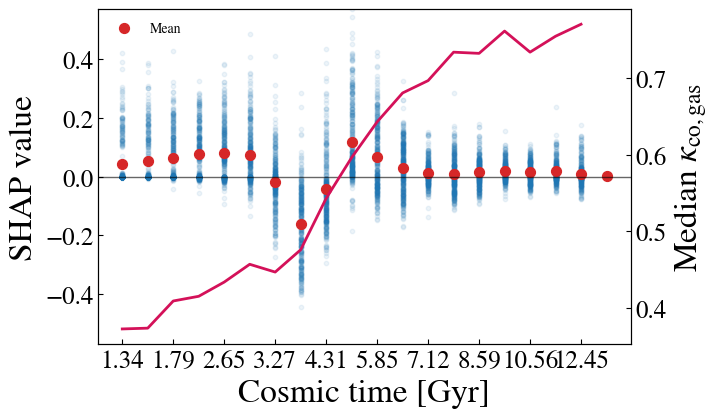

In [190]:
event_data = pd.read_csv('outputs/event_all.csv')

feat = X_test_scaled[:, :, 0]  # (N, T)
feat_masked = np.where(feat > -10, feat, np.nan)
median_feature = np.nanmedian(feat_masked, axis=0)  # (T,)

times = event_data['t (event index)'].unique()
times = np.sort(times)

# choose sparse ticks
idx = np.linspace(0, len(times)-2, int(len(times-2)/2), dtype=int)

fig, ax = plot_global_event_timeshap(
    event_data,
    time_col='t (event index)',
    shap_col='Shapley Value',
    figsize=(7, 4),
    percentile_clip=None
)

ax2 = ax.twinx()
ax2.plot(times[:-1], median_feature, c='#D41159', lw=2)
ax2.set_ylabel('Median $\\kappa_{\\rm co,\\star}$')

ax.set_xticks(times[idx])
ax.set_xticklabels(np.round(t_cosmic[idx], 2))
ax.set_xlabel('Cosmic time [Gyr]')
ax.legend(loc='upper left')
plt.show()


feat = X_test_scaled[:, :, 1]  # (N, T)
feat_masked = np.where(feat > -10, feat, np.nan)
median_feature = np.nanmedian(feat_masked, axis=0)  # (T,)

times = event_data['t (event index)'].unique()
times = np.sort(times)

# choose sparse ticks
idx = np.linspace(0, len(times)-2, int(len(times-2)/2), dtype=int)

fig, ax = plot_global_event_timeshap(
    event_data,
    time_col='t (event index)',
    shap_col='Shapley Value',
    figsize=(7, 4),
    percentile_clip=None
)

ax2 = ax.twinx()
ax2.plot(times[:-1], median_feature, c='#D41159', lw=2)
ax2.set_ylabel('Median $\\kappa_{\\rm co,gas}$')

ax.set_xticks(times[idx])
ax.set_xticklabels(np.round(t_cosmic[idx], 2))
ax.set_xlabel('Cosmic time [Gyr]')
ax.legend(loc='upper left')
plt.show()


The figure layout has changed to tight


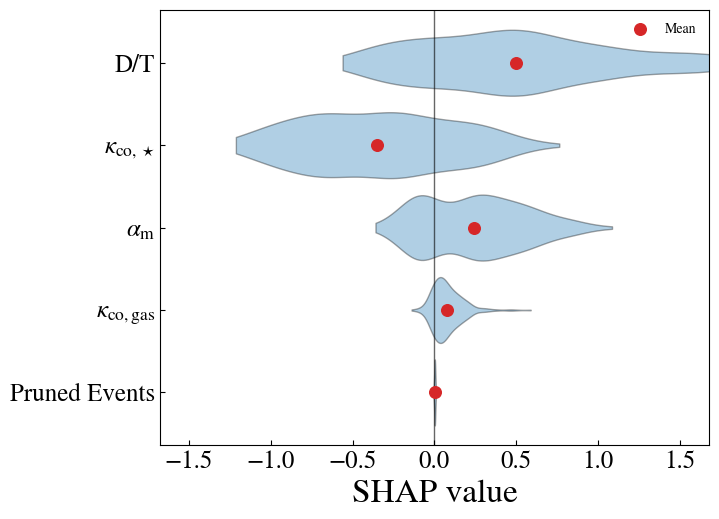

The figure layout has changed to tight


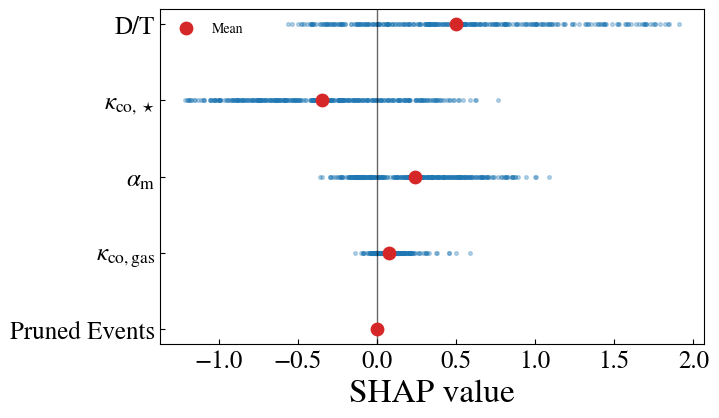

In [194]:
feat_data = pd.read_csv('outputs/feature_all.csv')

fig, ax = plot_global_feat_violin(
    feat_data,
    axis_percentiles=(1, 99),
    figsize=(7, 5)
)

plt.show()

v = feat_data['Shapley Value'].dropna().values
_, hi = np.percentile(np.abs(v), [1, 99])

fig, ax = plot_global_feat_matplotlib(
    feat_data,
    axis_lim=None,
    figsize=(7, 4)
)


Low rows: 228
High rows: 228


All-NaN slice encountered


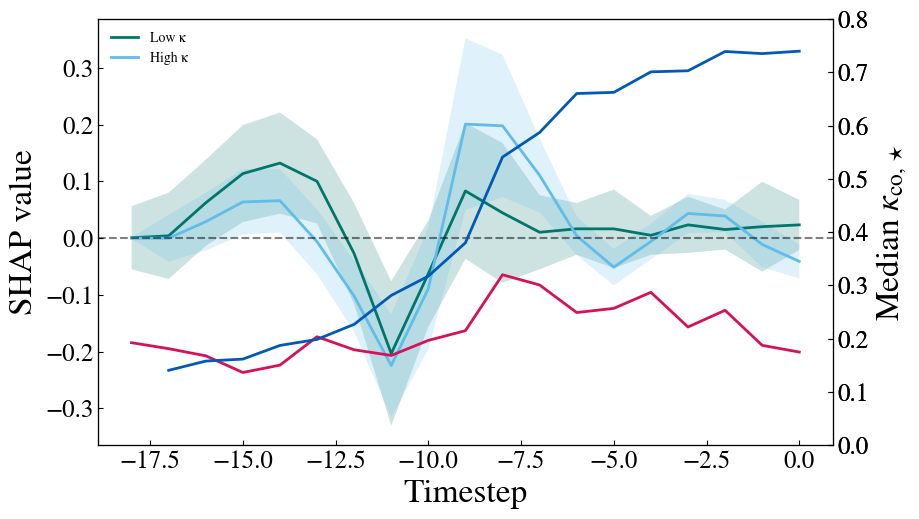

In [229]:
event_data = pd.read_csv('outputs/event_all.csv')

low_entity_ids = np.where(np.isin(ellspi_test, low_kappa_ids))[0]
high_entity_ids = np.where(np.isin(ellspi_test, high_kappa_ids))[0]

event_data['Entity'] = event_data['Entity'].astype(int)
event_low  = event_data[event_data['Entity'].isin(low_entity_ids)]
event_high = event_data[event_data['Entity'].isin(high_entity_ids)]

median_low  = event_low.groupby('t (event index)')['Shapley Value'].median()
median_high = event_high.groupby('t (event index)')['Shapley Value'].median()

# Align time indices
times = np.sort(event_data['t (event index)'].unique())

median_low  = median_low.reindex(times)
median_high = median_high.reindex(times)

diff = median_high - median_low

low_stats = event_low.groupby('t (event index)')['Shapley Value'].agg(['median','std'])
high_stats = event_high.groupby('t (event index)')['Shapley Value'].agg(['median','std'])

print("Low rows:", len(event_low))
print("High rows:", len(event_high))

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(times[:-1], low_stats['median'], label='Low κ', lw=2)
ax.fill_between(times[:-1],
                low_stats['median'] - low_stats['std'],
                low_stats['median'] + low_stats['std'],
                alpha=0.2)

feat = X_test_scaled[low_entity_ids, :, 0]  # (N, T)
feat_masked = np.where(feat > -10, feat, np.nan)
median_feature = np.nanmedian(feat_masked, axis=0)  # (T,)

ax2 = ax.twinx()
ax2.plot(times[:-1], median_feature, c='#D41159', lw=2, label='Upper quartile')
ax2.set_ylabel('Median $\\kappa_{\\rm co,\\star}$')
ax2.set_ylim(0, 0.8)

ax.plot(times[:-1], high_stats['median'], label='High κ', lw=2)
ax.fill_between(times[:-1],
                high_stats['median'] - high_stats['std'],
                high_stats['median'] + high_stats['std'],
                alpha=0.2)

feat = X_test_scaled[high_entity_ids, :, 0]  # (N, T)
feat_masked = np.where(feat > -10, feat, np.nan)
median_feature = np.nanmedian(feat_masked, axis=0)  # (T,)

ax2 = ax.twinx()
ax2.plot(times[:-1], median_feature, c='#005AB5', lw=2, label='Lower quartile')
ax2.set_ylim(0, 0.8)

ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('SHAP value')
ax.legend(loc='upper left')

plt.show()

In [230]:
# 1️⃣ Start from the original split
train_mask_full = ~np.isin(matched_group_nums, test_kappa_ids)  # True for training galaxies
train_idx_full = np.where(train_mask_full)[0]  # indices in full array

# 2️⃣ Extract e_bind for only training galaxies
e_bind_train = e_bind[train_idx_full]

# 3️⃣ Mask for the binding energy range within training galaxies
ebind_range_train = (e_bind_train >= 58) & (e_bind_train <= 58.5)

# 4️⃣ Indices of selected galaxies in the training subset
# Find their positions in X_train_scaled (axis 0)
selected_train_idx_in_X_train = np.where(ebind_range_train)[0]

# ✅ Compute baseline_event only for these galaxies
baseline_event = np.mean(X_train_scaled[selected_train_idx_in_X_train], axis=0)  # shape (T, F)



model_wrapped = TorchModelWrapper(model)

def f_hs(x, y=None):
    """
    x: np.ndarray of shape (N, T, F)
    returns: (N,) or (N, 1)
    """
    return model_wrapped.predict_last_hs(x, y)

model_features = feature_names

plot_features = {
    r'$\kappa_{\rm co,\star}$': r'$\kappa_{\rm co,\star}$',
    r'$\kappa_{\rm co,gas}$': r'$\kappa_{\rm co,gas}$',
    r'$\alpha_{\rm m}$': r'$\alpha_{\rm m}$',
    'D/T': 'D/T'
}

pruning_dict = {
    'tol': [0.0001],   # Small tolerance
    'path': 'outputs_ebind/prun_all.csv'
}

event_dict = {
    'path': 'outputs_ebind/event_all.csv',
    'rs': 42,
    'nsamples': 32000
}

feature_dict = {
    'path': 'outputs_ebind/feature_all.csv',
    'rs': 42,
    'nsamples': 32000,
    'feature_names': model_features,   # list of column names
    'plot_features': plot_features     # dict (THIS FIXES THE ERROR)
}


schema = list(df_test.columns)

sequence_id_feat = 'sequence_id'
time_feat = 'time'

print(schema)

set(model_features).issubset(set(schema))

print(df_test[sequence_id_feat].nunique())  # number of sequences
print(df_test.groupby(sequence_id_feat).size().unique())  # length of sequences

df_test['sequence_id'] = df_test['sequence_id'].astype(int)
df_test['time'] = df_test['time'].astype(int)

for col in feature_names:
    df_test[col] = pd.to_numeric(df_test[col])
    
df_range = df_test[df_test['sequence_id'].isin(np.where(ebind_range)[0])]
    
prun_stats, global_plot = global_report(
    f_hs,
    df_range,
    pruning_dict,
    event_dict,
    feature_dict,
    baseline_event,
    model_features,
    schema,
    sequence_id_feat,
    time_feat,
    append_to_files=True
)

['sequence_id', 'time', '$\\kappa_{\\rm co,\\star}$', '$\\kappa_{\\rm co,gas}$', '$\\alpha_{\\rm m}$', 'D/T']
338
[19]
Calculating pruning algorithm
Calculating event data
Calculating feat data
Calculating pruning indexes


elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


[321]
                   median  std
t (event index)               
-18              0.153729  0.0
-17              0.214923  0.0
-16              0.219841  0.0
-15              0.207029  0.0
-14              0.180982  0.0
-13              0.143370  0.0
-12              0.072434  0.0
-11              0.024077  0.0
-10              0.209487  0.0
-9               0.281013  0.0
-8              -0.052763  0.0
-7              -0.024852  0.0
-6               0.090718  0.0
-5               0.077468  0.0
-4               0.049383  0.0
-3              -0.004723  0.0
-2               0.046979  0.0
-1               0.106255  0.0
 0               0.102838  0.0
 1                    NaN  0.0
19


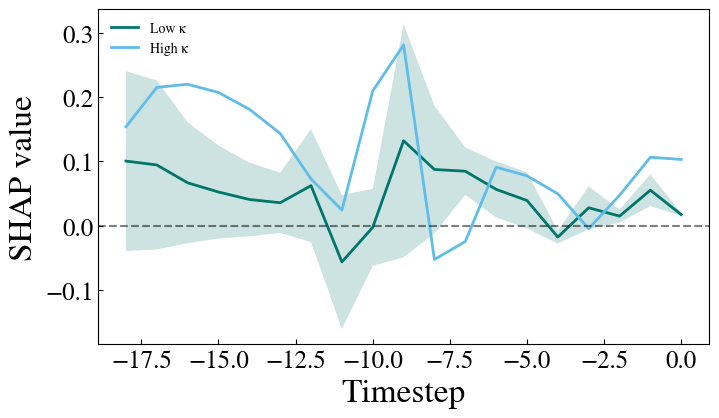

In [223]:
entity_ids_in_range = df_range['sequence_id'].unique()  # e.g., array([10, 22, 35])
full_idx_in_range = np.array([np.where(matched_group_nums == sid)[0][0] for sid in entity_ids_in_range])

kappa_subset = kappa_co[full_idx_in_range]
low_kappa_ids_range  = entity_ids_in_range[kappa_subset <= low_kappa]
high_kappa_ids_range = entity_ids_in_range[kappa_subset >= high_kappa]


event_data['Entity'] = event_data['Entity'].astype(int)

event_low  = event_data[event_data['Entity'].isin(low_kappa_ids_range)]
event_high = event_data[event_data['Entity'].isin(high_kappa_ids_range)]

low_stats  = event_low.groupby('t (event index)')['Shapley Value'].agg(['median','std'])
high_stats = event_high.groupby('t (event index)')['Shapley Value'].agg(['median','std'])

times = np.sort(event_data['t (event index)'].unique())
low_stats  = low_stats.reindex(times)
high_stats = high_stats.reindex(times)

low_stats['std'] = low_stats['std'].fillna(0)
high_stats['std'] = high_stats['std'].fillna(0)

print(high_kappa_ids_range)

print(high_stats)
print(len(event_high))

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(times, low_stats['median'], label='Low κ', lw=2)
ax.fill_between(times,
                low_stats['median'] - low_stats['std'],
                low_stats['median'] + low_stats['std'],
                alpha=0.2)

ax.plot(times, high_stats['median'], label='High κ', lw=2)
ax.fill_between(times,
                high_stats['median'] - high_stats['std'],
                high_stats['median'] + high_stats['std'],
                alpha=0.2)

# # Optional difference curve
# diff = high_stats['median'] - low_stats['median']
# ax2 = ax.twinx()
# ax2.plot(times, diff, color='grey', lw=2, ls='--', label='High - Low SHAP')
# ax2.set_ylabel('SHAP difference')
# ax2.axhline(0, color='k', ls=':', alpha=0.5)

ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('SHAP value')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()
